In [140]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = (
    NOTEBOOK_DIR.parent
    if NOTEBOOK_DIR.name == "notebooks"
    else NOTEBOOK_DIR
)

for path in (PROJECT_DIR, PROJECT_DIR / "src"):  # src/: modules import each other as crypto_impact.*
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from src.crypto_impact.binning import (
    bin_impact_curve_with_uncertainty,
)
from src.crypto_impact.impact import (
    add_trailing_impact_normalisation,
)
from src.crypto_impact.monthly_eda import (
    build_fixed_event_bars,
    load_monthly_trades,
    make_time_bars,
)
from src.crypto_impact.regime_analysis import (
    build_analysis_table,
)
from src.crypto_impact.regression import (
    compare_impact_models,
)

# Corrected trade events (one event per same-sign run of fills at a millisecond
# timestamp, priced at the run's last fill; scripts/export_paper_events.py), on the
# shared data drive. The legacy files in data/raw/BTCUSDT_monthly (first-fill price
# and sign per timestamp, 2025-01..2026-05) are no longer used.
SHARED_ACADEMIC = PROJECT_DIR.parent / "shared-data" / "features" / "academic" / "symbol=BTCUSDT"
DATA_DIR = Path(os.environ.get("CRYPTO_IMPACT_DATA_DIR", SHARED_ACADEMIC / "paper_events_v2"))
SAMPLE_START = os.environ.get("CRYPTO_IMPACT_SAMPLE_START", "2021-01")
SAMPLE_END = os.environ.get("CRYPTO_IMPACT_SAMPLE_END", "2026-08")
assert SAMPLE_END <= "2026-08", "Data from 2026-09 onward is reserved for the alpha-search P-006 test."

# Redo outputs sit beside the other full-sample notebook reruns, so the paper's
# original reports/figures and reports/tables are not overwritten.
FIGURE_DIR = Path(os.environ.get("CRYPTO_IMPACT_FIGURE_DIR", PROJECT_DIR / "reports" / "redo" / "paper" / "figures"))
TABLE_DIR = Path(os.environ.get("CRYPTO_IMPACT_TABLE_DIR", PROJECT_DIR / "reports" / "redo" / "paper" / "tables"))

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

FILES = sorted(
    path for path in DATA_DIR.glob("BTCUSDT-trades-*.parquet")
    if SAMPLE_START <= path.stem.removeprefix("BTCUSDT-trades-") <= SAMPLE_END
)
print(f"Files selected: {len(FILES)} ({FILES[0].name} to {FILES[-1].name})")

EVENT_COUNTS = [
    100,
    250,
    500,
    1_000,
    2_000,
    4_000,
    8_000,
    16_000,
]

N_BINS = 60  # equal-count bins for every event-bar and time-bar fit
# Bar sizes reported in Table tab:event-bar-robustness; also the sizes over which the
# common normalised-imbalance support is defined.
TABLE_EVENT_COUNTS = [250, 500, 1_000, 2_000, 4_000, 8_000, 16_000]
BIN_SENSITIVITY_EVENT_SIZES = [4_000, 16_000]
MIN_OBS_PER_BIN = 20
BASE_WINDOW = "2min"
BASE_BARS_PER_DAY = int(pd.Timedelta("1D") / pd.Timedelta(BASE_WINDOW))
# The trailing 24 h benchmark needs 90% of a day's benchmark bars: this excludes the
# sample's first day and any trailing day missing more than ~2.4 h, but keeps days
# containing short exchange pauses (a strict full-day rule would drop a whole day
# after every pause).
MIN_BENCHMARK_BARS = int(0.9 * BASE_BARS_PER_DAY)

In [141]:
base_frames = []

for file in FILES:
    print(f"Building benchmark bars from {file.name}")

    events = load_monthly_trades(file)
    time_bars = make_time_bars(
        events,
        window=BASE_WINDOW,
    )

    base_frames.append(time_bars)

base_bars = pd.concat(base_frames).sort_index()

base_bars["duration_seconds"] = pd.Timedelta(BASE_WINDOW).total_seconds()
base_bars["current_return_bps"] = (
    base_bars["log_return_bps"]
)
base_bars["end_time"] = (
    base_bars.index
    + pd.Timedelta(BASE_WINDOW)
)

base_benchmark = add_trailing_impact_normalisation(
    base_bars,
    window="1D",
    min_periods=MIN_BENCHMARK_BARS,
    timestamp_col=None,
)

benchmark_columns = [
    "trailing_market_volume",
    "trailing_realised_volatility_bps",
]

base_benchmark = (
    base_benchmark[benchmark_columns]
    .dropna()
    .sort_index()
)

base_benchmark.head()

Building benchmark bars from BTCUSDT-trades-2025-01.parquet
Building benchmark bars from BTCUSDT-trades-2025-02.parquet
Building benchmark bars from BTCUSDT-trades-2025-03.parquet
Building benchmark bars from BTCUSDT-trades-2025-04.parquet
Building benchmark bars from BTCUSDT-trades-2025-05.parquet
Building benchmark bars from BTCUSDT-trades-2025-06.parquet
Building benchmark bars from BTCUSDT-trades-2025-07.parquet
Building benchmark bars from BTCUSDT-trades-2025-08.parquet
Building benchmark bars from BTCUSDT-trades-2025-09.parquet
Building benchmark bars from BTCUSDT-trades-2025-10.parquet
Building benchmark bars from BTCUSDT-trades-2025-11.parquet
Building benchmark bars from BTCUSDT-trades-2025-12.parquet
Building benchmark bars from BTCUSDT-trades-2026-01.parquet
Building benchmark bars from BTCUSDT-trades-2026-02.parquet
Building benchmark bars from BTCUSDT-trades-2026-03.parquet
Building benchmark bars from BTCUSDT-trades-2026-04.parquet
Building benchmark bars from BTCUSDT-tra

,trailing_market_volume,trailing_realised_volatility_bps
timestamp,,
2025-01-01 09:36:00+00:00,31762.979,90.490051
2025-01-01 09:38:00+00:00,31917.309,91.436247
2025-01-01 09:40:00+00:00,32092.091,91.450851
2025-01-01 09:42:00+00:00,32248.924,91.530422
2025-01-01 09:44:00+00:00,32457.708,91.565544


In [142]:
def attach_common_benchmark(
    event_bars: pd.DataFrame,
    benchmark: pd.DataFrame,
) -> pd.DataFrame:
    analysis = build_analysis_table(
        event_bars.drop(
            columns=["high_low_range_bps"],
            errors="ignore",
        ),
        horizons=(),
    )

    left = (
        analysis
        .sort_index()
        .rename_axis("start_time")
        .reset_index()
    )

    right = (
        benchmark
        .sort_index()
        .rename_axis("benchmark_time")
        .reset_index()
    )

    left = left.sort_values("start_time")
    right = right.sort_values("benchmark_time")
    
    merged = pd.merge_asof(
        left,
        right,
        left_on="start_time",
        right_on="benchmark_time",
        direction="backward",
    )

    merged["signed_current_impact_bps"] = (
        np.sign(merged["signed_imbalance"])
        * merged["current_return_bps"]
    )

    merged["normalised_imbalance"] = (
        merged["signed_imbalance"].abs()
        / merged["trailing_market_volume"]
    )

    merged["normalised_signed_impact"] = (
        merged["signed_current_impact_bps"]
        / merged["trailing_realised_volatility_bps"]
    )

    merged.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True,
    )

    return merged.set_index("start_time")

In [144]:
analyses_by_size = {}

for events_per_bar in EVENT_COUNTS:
    print(f"\nBuilding {events_per_bar:,}-event bars")

    bars_n = build_fixed_event_bars(
        FILES,
        events_per_bar=events_per_bar,
    )

    analysis_n = attach_common_benchmark(
        bars_n,
        base_benchmark,
    )

    analyses_by_size[events_per_bar] = analysis_n

pooled_x_scale = float(
    analyses_by_size[4_000][
        "normalised_imbalance"
    ]
    .dropna()
    .median()
)

pooled_x_scale


Building 100-event bars

Building 250-event bars

Building 500-event bars

Building 1,000-event bars

Building 2,000-event bars

Building 4,000-event bars

Building 8,000-event bars

Building 16,000-event bars


0.0005542642720591806

In [143]:
# Zero-range diagnostic on the last bar size built in the loop above (16,000 events).
zero_range = bars_n.loc[
    bars_n["high_low_range_bps"] <= 0,
    [
        "end_time",
        "trade_count",
        "start_price",
        "end_price",
        "high_price",
        "low_price",
        "high_low_range_bps",
    ],
]

print(len(zero_range))
display(zero_range.head())

0


,end_time,trade_count,start_price,end_price,high_price,low_price,high_low_range_bps
start_time,,,,,,,


In [145]:
comparison_rows = []
predictions_by_size = []

for events_per_bar, analysis_n in analyses_by_size.items():
    sample = analysis_n[
        [
            "normalised_imbalance",
            "normalised_signed_impact",
        ]
    ].dropna()

    curve = bin_impact_curve_with_uncertainty(
        sample,
        x_col="normalised_imbalance",
        impact_col="normalised_signed_impact",
        n_bins=N_BINS,
        method="equal_count",
    )

    comparison, predictions = compare_impact_models(
        curve,
        min_obs_per_bin=MIN_OBS_PER_BIN,
        x_scale=pooled_x_scale,
    )

    fitted = comparison.set_index("model")

    comparison_rows.append(
        {
            "events_per_bar": events_per_bar,
            "bars_used": len(sample),
            "median_duration_seconds": (
                analysis_n["duration_seconds"].median()
            ),
            "median_gross_volume_btc": (
                analysis_n["gross_volume"].median()
            ),
            "free_power_delta": fitted.loc[
                "free_power", "delta"
            ],
            "log_wrmse": fitted.loc[
                "logarithmic", "weighted_rmse"
            ],
            "power_wrmse": fitted.loc[
                "free_power", "weighted_rmse"
            ],
            "square_root_wrmse": fitted.loc[
                "square_root", "weighted_rmse"
            ],
            "log_wrmse_improvement_pct": 100 * (
                fitted.loc[
                    "free_power", "weighted_rmse"
                ]
                - fitted.loc[
                    "logarithmic", "weighted_rmse"
                ]
            ) / fitted.loc[
                "free_power", "weighted_rmse"
            ],
            "bins_used": fitted.loc[
                "free_power", "bins_used"
            ],
        }
    )

    predictions["events_per_bar"] = events_per_bar
    predictions_by_size.append(predictions)

bar_size_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("events_per_bar")
    .reset_index(drop=True)
)

bar_size_predictions = pd.concat(
    predictions_by_size,
    ignore_index=True,
)

bar_size_comparison

,events_per_bar,bars_used,median_duration_seconds,median_gross_volume_btc,free_power_delta,log_wrmse,power_wrmse,square_root_wrmse,log_wrmse_improvement_pct,bins_used
0,100,4590420,6.9590,13.1710,0.475702,0.000218,0.000447,0.000472,51.136026,120
1,250,1836168,18.1470,36.5090,0.512444,0.000293,0.000833,0.000843,64.839359,120
2,500,918083,37.1390,77.1970,0.536992,0.000421,0.001167,0.001284,63.947229,120
3,1000,459041,75.6150,161.4340,0.569135,0.000690,0.001599,0.002111,56.850599,120
4,2000,229520,153.9020,334.4505,0.603630,0.001107,0.002172,0.003583,49.052423,120
5,4000,114760,313.0425,688.5295,0.628554,0.002109,0.002754,0.005603,23.449571,120
6,8000,57380,637.5055,1406.7775,0.669147,0.003423,0.003908,0.009584,12.410645,120
7,16000,28690,1300.1100,2866.0630,0.699889,0.005973,0.005719,0.015109,-4.428964,120


In [ ]:
# Export Table tab:event-bar-robustness. The CSV (event_bar_size_robustness.csv, written
# below with the figure) keeps every bar size and full precision; the .tex file is the
# tabular body for the sizes reported in the thesis.

def _signed(value, decimals):
    text = f"{abs(value):,.{decimals}f}"
    return f"$-${text}" if value < 0 and float(text.replace(",", "")) != 0 else text


lines = [
    r"\begin{tabular}{rrrrrr}",
    r"\toprule",
    r"Events per bar & Bars used & Median duration & Median volume & Free-power $\delta$ & Log improvement \\",
    r" & & (seconds) & (BTC) & & (\%) \\",
    r"\midrule",
]
for row in bar_size_comparison.loc[bar_size_comparison["events_per_bar"].isin(TABLE_EVENT_COUNTS)].itertuples():
    lines.append(" & ".join([
        f"{row.events_per_bar:,}", f"{row.bars_used:,}", f"{row.median_duration_seconds:,.1f}",
        f"{row.median_gross_volume_btc:,.1f}", f"{row.free_power_delta:.3f}",
        _signed(row.log_wrmse_improvement_pct, 1),
    ]) + r" \\")
lines += [r"\bottomrule", r"\end{tabular}"]
(TABLE_DIR / "event_bar_robustness.tex").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

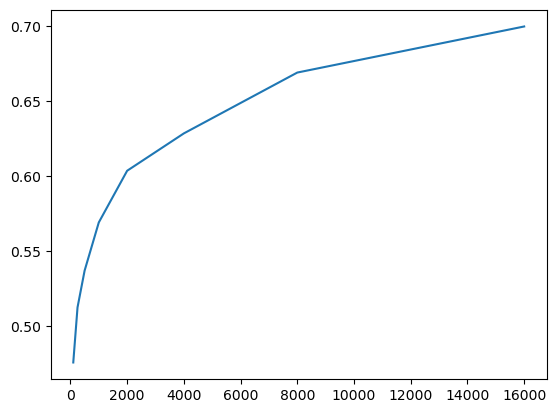

In [146]:
plt.plot((bar_size_comparison["events_per_bar"].astype('float64')), bar_size_comparison["free_power_delta"].astype('float64'))

plt.show()

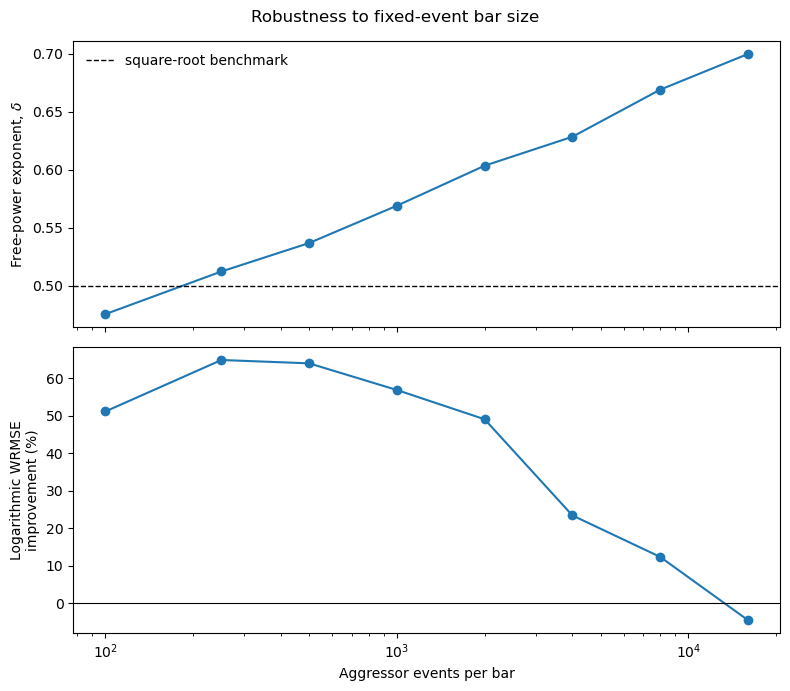

In [147]:
bar_size_comparison.to_csv(
    TABLE_DIR / "event_bar_size_robustness.csv",
    index=False,
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 7),
    sharex=True,
)

axes[0].plot(
    bar_size_comparison["events_per_bar"],
    bar_size_comparison["free_power_delta"],
    marker="o",
)

axes[0].axhline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=1,
    label="square-root benchmark",
)

axes[0].set_ylabel(
    r"Free-power exponent, $\delta$"
)
axes[0].legend(frameon=False)

axes[1].plot(
    bar_size_comparison["events_per_bar"],
    bar_size_comparison[
        "log_wrmse_improvement_pct"
    ],
    marker="o",
)

axes[1].axhline(
    0,
    color="black",
    linewidth=0.8,
)

axes[1].set_xscale("log")
axes[1].set_xlabel("Aggressor events per bar")
axes[1].set_ylabel(
    "Logarithmic WRMSE\nimprovement (%)"
)

fig.suptitle(
    "Robustness to fixed-event bar size"
)
fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "07_event_bar_size_robustness.pdf",
    bbox_inches="tight",
)

plt.show()


In [148]:
# Common support: the overlap of the 1%-99% normalised-imbalance ranges of the bar
# sizes reported in Table tab:event-bar-robustness.
support_by_size = (
    pd.DataFrame(
        {
            events_per_bar: {
                "q01": analysis_n[
                    "normalised_imbalance"
                ].quantile(0.01),
                "q99": analysis_n[
                    "normalised_imbalance"
                ].quantile(0.99),
            }
            for events_per_bar, analysis_n
            in analyses_by_size.items()
            if events_per_bar in TABLE_EVENT_COUNTS
        }
    )
    .T
)

support_by_size

,q01,q99
100,4.257292e-07,0.000576
250,9.104298e-07,0.001035
500,1.643802e-06,0.001617
1000,2.931592e-06,0.002509
2000,5.123726e-06,0.003901
4000,8.696309e-06,0.006007
8000,1.422792e-05,0.009094
16000,2.180678e-05,0.013626


In [149]:
common_lower_x = support_by_size["q01"].max()
common_upper_x = support_by_size["q99"].min()

common_lower_x, common_upper_x

(2.180677912082792e-05, 0.0005760450615495385)

In [157]:
common_support_rows = []

for events_per_bar in TABLE_EVENT_COUNTS:
    analysis_n = analyses_by_size[events_per_bar]
    sample = analysis_n.loc[
        analysis_n["normalised_imbalance"].between(
            common_lower_x,
            common_upper_x,
        ),
        [
            "normalised_imbalance",
            "normalised_signed_impact",
        ],
    ].dropna()

    curve = bin_impact_curve_with_uncertainty(
        sample,
        x_col="normalised_imbalance",
        impact_col="normalised_signed_impact",
        n_bins=N_BINS,
        method="equal_count",
    )

    comparison, _ = compare_impact_models(
        curve,
        min_obs_per_bin=MIN_OBS_PER_BIN,
        x_scale=pooled_x_scale,
    )

    fitted = comparison.set_index("model")

    common_support_rows.append(
        {
            "events_per_bar": events_per_bar,
            "bars_used": len(sample),
            "free_power_delta": fitted.loc[
                "free_power", "delta"
            ],
            "log_wrmse": fitted.loc[
                "logarithmic", "weighted_rmse"
            ],
            "power_wrmse": fitted.loc[
                "free_power", "weighted_rmse"
            ],
            "log_wrmse_improvement_pct": 100 * (
                fitted.loc[
                    "free_power", "weighted_rmse"
                ]
                - fitted.loc[
                    "logarithmic", "weighted_rmse"
                ]
            ) / fitted.loc[
                "free_power", "weighted_rmse"
            ],
        }
    )

common_support_comparison = pd.DataFrame(
    common_support_rows
).sort_values("events_per_bar")

In [155]:
common_support_comparison.to_csv(TABLE_DIR / "event_bar_common_support_robustness.csv", index=False)
common_support_comparison


,events_per_bar,bars_used,free_power_delta,log_wrmse,power_wrmse,log_wrmse_improvement_pct
0,1000,419964,0.582257,0.000480,0.001468,67.302934
1,2000,213033,0.637576,0.000829,0.001889,56.116685
2,4000,103378,0.681150,0.001610,0.002218,27.416114
3,8000,47065,0.753468,0.002909,0.003049,4.584596
4,16000,19718,0.797873,0.006312,0.006445,2.070340


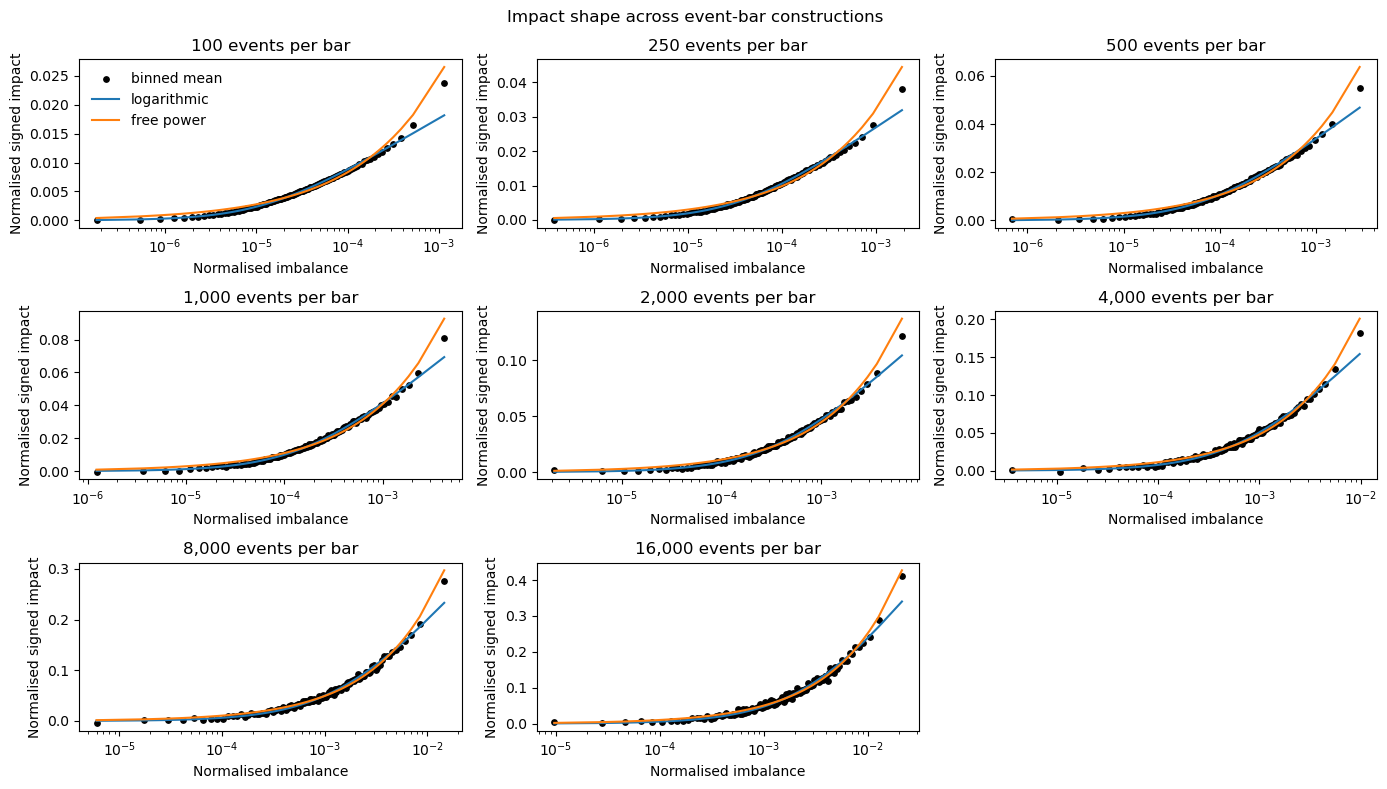

In [158]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(14, 8),
    sharex=False,
    sharey=False,
)

for ax, events_per_bar in zip(
    axes.ravel(),
    EVENT_COUNTS,
):
    analysis_n = analyses_by_size[events_per_bar]

    sample = analysis_n[
        [
            "normalised_imbalance",
            "normalised_signed_impact",
        ]
    ].dropna()

    curve = bin_impact_curve_with_uncertainty(
        sample,
        x_col="normalised_imbalance",
        impact_col="normalised_signed_impact",
        n_bins=N_BINS,
        method="equal_count",
    )

    comparison, predictions = compare_impact_models(
        curve,
        min_obs_per_bin=MIN_OBS_PER_BIN,
        x_scale=pooled_x_scale,
    )

    ax.scatter(
        curve["mean_x"],
        curve["mean_impact"],
        s=15,
        color="black",
        label="binned mean",
    )

    for model, colour in [
        ("logarithmic", "tab:blue"),
        ("free_power", "tab:orange"),
    ]:
        group = predictions.loc[
            predictions["model"] == model
        ].sort_values("x")

        ax.plot(
            group["x"],
            group["predicted_impact"],
            color=colour,
            label=model.replace("_", " "),
        )

    ax.set_xscale("log")
    ax.set_title(
        f"{events_per_bar:,} events per bar"
    )
    ax.set_xlabel("Normalised imbalance")
    ax.set_ylabel("Normalised signed impact")

axes.ravel()[-1].axis("off")
axes.ravel()[0].legend(frameon=False)

fig.suptitle(
    "Impact shape across event-bar constructions"
)
fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "08_event_bar_fitted_curves.pdf",
    bbox_inches="tight",
)

plt.show()

In [159]:
def bin_model_diagnostics(
    curve,
    predictions,
):
    observed = curve[
        [
            "bin_id",
            "mean_x",
            "mean_impact",
            "standard_error",
            "n_obs",
        ]
    ].copy()

    fitted = (
        predictions
        .pivot(
            index="x",
            columns="model",
            values="predicted_impact",
        )
        .reset_index()
        .rename(columns={"x": "mean_x"})
    )

    diagnostics = observed.merge(
        fitted,
        on="mean_x",
        how="inner",
    )

    diagnostics["weight"] = (
        1
        / diagnostics["standard_error"].pow(2)
    )

    diagnostics["log_weighted_squared_error"] = (
        diagnostics["weight"]
        * (
            diagnostics["mean_impact"]
            - diagnostics["logarithmic"]
        ).pow(2)
    )

    diagnostics["power_weighted_squared_error"] = (
        diagnostics["weight"]
        * (
            diagnostics["mean_impact"]
            - diagnostics["free_power"]
        ).pow(2)
    )

    diagnostics["log_minus_power_contribution"] = (
        diagnostics["log_weighted_squared_error"]
        - diagnostics["power_weighted_squared_error"]
    )

    return diagnostics.sort_values("mean_x")

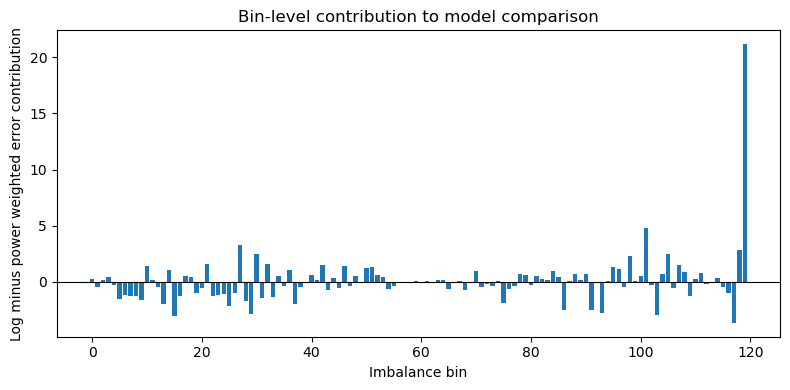

In [160]:
diagnostics = bin_model_diagnostics(
    curve,
    predictions,
)

plt.figure(figsize=(8, 4))

plt.bar(
    diagnostics["bin_id"],
    diagnostics["log_minus_power_contribution"],
)

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Imbalance bin")
plt.ylabel("Log minus power weighted error contribution")
plt.title("Bin-level contribution to model comparison")
plt.tight_layout()
plt.show()

In [161]:
tail_sensitivity_rows = []

ordered_curve = curve.sort_values(
    "mean_x"
).reset_index(drop=True)

for upper_bins_excluded in range(0, 5):
    if upper_bins_excluded == 0:
        fitted_curve = ordered_curve.copy()
    else:
        fitted_curve = ordered_curve.iloc[
            :-upper_bins_excluded
        ].copy()

    comparison, _ = compare_impact_models(
        fitted_curve,
        min_obs_per_bin=100,
        x_scale=pooled_x_scale,
    )

    fitted = comparison.set_index("model")

    tail_sensitivity_rows.append(
        {
            "upper_bins_excluded": upper_bins_excluded,
            "bins_used": len(fitted_curve),
            "free_power_delta": fitted.loc[
                "free_power", "delta"
            ],
            "log_wrmse": fitted.loc[
                "logarithmic", "weighted_rmse"
            ],
            "power_wrmse": fitted.loc[
                "free_power", "weighted_rmse"
            ],
            "log_wrmse_improvement_pct": 100 * (
                fitted.loc[
                    "free_power", "weighted_rmse"
                ]
                - fitted.loc[
                    "logarithmic", "weighted_rmse"
                ]
            ) / fitted.loc[
                "free_power", "weighted_rmse"
            ],
        }
    )

tail_sensitivity = pd.DataFrame(
    tail_sensitivity_rows
)

tail_sensitivity.to_csv(TABLE_DIR / "event_bar_tail_sensitivity_16000.csv", index=False)
tail_sensitivity


,upper_bins_excluded,bins_used,free_power_delta,log_wrmse,power_wrmse,log_wrmse_improvement_pct
0,0,120,0.699889,0.005973,0.005719,-4.428964
1,1,119,0.704313,0.005324,0.005683,6.304086
2,2,118,0.707269,0.005124,0.005664,9.528999
3,3,117,0.713939,0.005120,0.005529,7.397358
4,4,116,0.717600,0.005116,0.005474,6.543425


In [162]:
# Bin-count sensitivity at the baseline (4,000) and largest (16,000) bar sizes.
bin_count_rows = []

for events_per_bar in BIN_SENSITIVITY_EVENT_SIZES:
    sample = analyses_by_size[events_per_bar][
        ["normalised_imbalance", "normalised_signed_impact"]
    ].dropna()

    for n_bins in [40, 60, 80, 100, 120, 240]:
        refined_curve = bin_impact_curve_with_uncertainty(
            sample,
            x_col="normalised_imbalance",
            impact_col="normalised_signed_impact",
            n_bins=n_bins,
            method="equal_count",
        )

        comparison, _ = compare_impact_models(
            refined_curve,
            min_obs_per_bin=100,
            x_scale=pooled_x_scale,
        )

        fitted = comparison.set_index("model")

        bin_count_rows.append(
            {
                "events_per_bar": events_per_bar,
                "n_bins": n_bins,
                "free_power_delta": fitted.loc[
                    "free_power", "delta"
                ],
                "log_wrmse": fitted.loc[
                    "logarithmic", "weighted_rmse"
                ],
                "power_wrmse": fitted.loc[
                    "free_power", "weighted_rmse"
                ],
                "log_wrmse_improvement_pct": 100 * (
                    fitted.loc[
                        "free_power", "weighted_rmse"
                    ]
                    - fitted.loc[
                        "logarithmic", "weighted_rmse"
                    ]
                ) / fitted.loc[
                    "free_power", "weighted_rmse"
                ],
            }
        )

bin_count_sensitivity = pd.DataFrame(bin_count_rows)
bin_count_sensitivity.to_csv(TABLE_DIR / "event_bar_bin_count_sensitivity.csv", index=False)
bin_count_sensitivity


,n_bins,free_power_delta,log_wrmse,power_wrmse,log_wrmse_improvement_pct
0,40,0.627453,0.001369,0.002445,44.029854
1,60,0.627709,0.001600,0.002472,35.278940
2,80,0.628182,0.001775,0.002546,30.287338
3,100,0.628461,0.001895,0.002622,27.711008
4,120,0.628554,0.002109,0.002754,23.449571
5,240,0.628919,0.002615,0.003089,15.339151


In [163]:
curve.tail(5)[
    [
        "mean_x",
        "mean_impact",
        "median_impact",
        "impact_p25",
        "impact_p75",
        "n_obs",
    ]
]

,mean_x,mean_impact,median_impact,impact_p25,impact_p75,n_obs
115,0.008243,0.213984,0.206453,0.139008,0.297188,239
116,0.009093,0.224589,0.217957,0.133056,0.310652,239
117,0.010441,0.240428,0.238401,0.155213,0.320834,239
118,0.012712,0.289522,0.269013,0.185355,0.381659,239
119,0.021318,0.410210,0.368134,0.268544,0.537551,240


In [164]:
TIME_WINDOWS = {
    "1min": 60,
    "150s": 150,
    "5min": 300,
    "10min": 600,
    "20min": 1_200,
}

In [165]:
time_bar_frames = {
    window: []
    for window in TIME_WINDOWS
}

for file in FILES:
    print(f"Processing {file.name}")

    events = load_monthly_trades(file)

    for window in TIME_WINDOWS:
        bars = make_time_bars(
            events,
            window=window,
        )
        time_bar_frames[window].append(bars)

time_bars_by_window = {}

for window, frames in time_bar_frames.items():
    bars = pd.concat(frames).sort_index()

    bars["duration_seconds"] = TIME_WINDOWS[window]
    bars["end_time"] = (
        bars.index
        + pd.Timedelta(seconds=TIME_WINDOWS[window])
    )

    time_bars_by_window[window] = bars

    print(window, len(bars))

Processing BTCUSDT-trades-2025-01.parquet
Processing BTCUSDT-trades-2025-02.parquet
Processing BTCUSDT-trades-2025-03.parquet
Processing BTCUSDT-trades-2025-04.parquet
Processing BTCUSDT-trades-2025-05.parquet
Processing BTCUSDT-trades-2025-06.parquet
Processing BTCUSDT-trades-2025-07.parquet
Processing BTCUSDT-trades-2025-08.parquet
Processing BTCUSDT-trades-2025-09.parquet
Processing BTCUSDT-trades-2025-10.parquet
Processing BTCUSDT-trades-2025-11.parquet
Processing BTCUSDT-trades-2025-12.parquet
Processing BTCUSDT-trades-2026-01.parquet
Processing BTCUSDT-trades-2026-02.parquet
Processing BTCUSDT-trades-2026-03.parquet
Processing BTCUSDT-trades-2026-04.parquet
Processing BTCUSDT-trades-2026-05.parquet
1min 743022
150s 297210
5min 148605
10min 74303
20min 37152


In [110]:
time_analyses = {}

for window, bars in time_bars_by_window.items():
    bars_for_analysis = bars.drop(
        columns=["high_low_range_bps"],
        errors="ignore",
    )

    analysis_t = attach_common_benchmark(
        bars_for_analysis,
        base_benchmark,
    )

    analysis_t = analysis_t.dropna(
        subset=[
            "normalised_imbalance",
            "normalised_signed_impact",
        ]
    )

    time_analyses[window] = analysis_t

In [111]:
time_rows = []
time_curves = {}
time_predictions = {}

for window, analysis_t in time_analyses.items():
    curve_t = bin_impact_curve_with_uncertainty(
        analysis_t,
        x_col="normalised_imbalance",
        impact_col="normalised_signed_impact",
        n_bins=N_BINS,
        method="equal_count",
    )

    comparison_t, predictions_t = compare_impact_models(
        curve_t,
        min_obs_per_bin=100,
        x_scale=pooled_x_scale,
    )

    fitted = comparison_t.set_index("model")

    time_rows.append({
        "window": window,
        "duration_seconds": TIME_WINDOWS[window],
        "bars_used": len(analysis_t),
        "median_trade_count": analysis_t["trade_count"].median(),
        "median_gross_volume_btc": analysis_t["gross_volume"].median(),
        "free_power_delta": fitted.loc["free_power", "delta"],
        "log_wrmse": fitted.loc["logarithmic", "weighted_rmse"],
        "power_wrmse": fitted.loc["free_power", "weighted_rmse"],
        "square_root_wrmse": fitted.loc[
            "square_root", "weighted_rmse"
        ],
        "log_wrmse_improvement_pct": (
            100
            * (
                fitted.loc["free_power", "weighted_rmse"]
                - fitted.loc["logarithmic", "weighted_rmse"]
            )
            / fitted.loc["free_power", "weighted_rmse"]
        ),
        "bins_used": fitted.loc["free_power", "bins_used"],
    })

    time_curves[window] = curve_t
    time_predictions[window] = predictions_t

time_bar_comparison = (
    pd.DataFrame(time_rows)
    .sort_values("duration_seconds")
    .reset_index(drop=True)
)

time_bar_comparison

,window,duration_seconds,bars_used,median_trade_count,median_gross_volume_btc,free_power_delta,log_wrmse,power_wrmse,square_root_wrmse,log_wrmse_improvement_pct,bins_used
0,1min,60,741582,420.0,57.2770,0.618267,0.000665,0.000841,0.001825,20.868904,60
1,150s,150,296634,1064.0,154.6190,0.659179,0.001078,0.001171,0.003476,7.943910,60
2,5min,300,148317,2156.0,326.0390,0.698857,0.001684,0.001489,0.005799,-13.094290,60
3,10min,600,74159,4375.0,684.0820,0.735098,0.002574,0.002036,0.009100,-26.423744,60
4,20min,1200,37080,8912.0,1437.7815,0.788699,0.003428,0.003485,0.015245,1.627757,60


In [ ]:
# Export Table tab:time-bar-robustness: CSV with full precision, .tex tabular body.
# WRMSE in units of 10^-3 (as in Table tab:impact-model-comparison).
time_bar_comparison.to_csv(TABLE_DIR / "time_bar_robustness.csv", index=False)
WINDOW_LABELS = {"1min": "1 minute", "150s": "2.5 minutes", "5min": "5 minutes",
                 "10min": "10 minutes", "20min": "20 minutes"}
lines = [
    r"\begin{tabular}{lrrrrrr}",
    r"\toprule",
    r"Time bar & Bars used & Median events & Free-power $\delta$ & Log WRMSE & Power WRMSE & Log improvement \\",
    r" & & & & ($\times 10^{-3}$) & ($\times 10^{-3}$) & (\%) \\",
    r"\midrule",
]
for row in time_bar_comparison.itertuples():
    lines.append(" & ".join([
        WINDOW_LABELS[row.window], f"{row.bars_used:,}", f"{row.median_trade_count:,.0f}",
        f"{row.free_power_delta:.3f}", f"{1_000 * row.log_wrmse:.2f}", f"{1_000 * row.power_wrmse:.2f}",
        _signed(row.log_wrmse_improvement_pct, 1),
    ]) + r" \\")
lines += [r"\bottomrule", r"\end{tabular}"]
(TABLE_DIR / "time_bar_robustness.tex").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

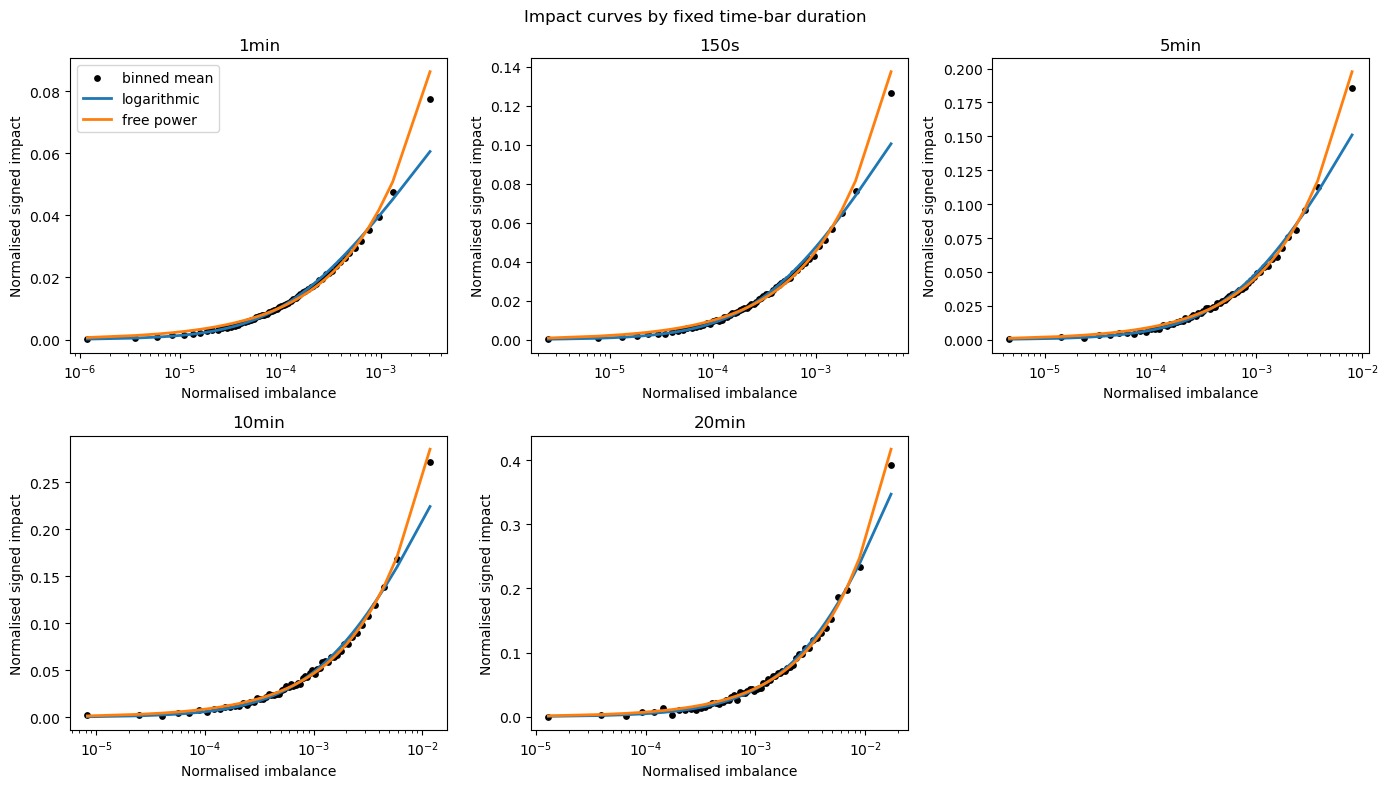

In [117]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False,
    sharey=False,
)

axes = axes.ravel()

for ax, (window, _) in zip(
    axes,
    sorted(
        TIME_WINDOWS.items(),
        key=lambda item: item[1],
    ),
):
    curve_t = time_curves[window]
    predictions_t = time_predictions[window]

    ax.scatter(
        curve_t["mean_x"],
        curve_t["mean_impact"],
        s=15,
        color="black",
        label="binned mean",
    )

    for model, colour in [
        ("logarithmic", "tab:blue"),
        ("free_power", "tab:orange"),
    ]:
        group = predictions_t.loc[
            predictions_t["model"] == model
        ].sort_values("x")

        ax.plot(
            group["x"],
            group["predicted_impact"],
            color=colour,
            linewidth=2,
            label=model.replace("_", " "),
        )

    ax.set_xscale("log")
    ax.set_title(window)
    ax.set_xlabel("Normalised imbalance")
    ax.set_ylabel("Normalised signed impact")

axes[0].legend()

for ax in axes[len(TIME_WINDOWS):]:
    ax.set_visible(False)

fig.suptitle("Impact curves by fixed time-bar duration")
fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "09_time_bar_fitted_curves.pdf",
    bbox_inches="tight",
)

plt.show()

In [115]:
time_fit_summary = []

for window, analysis_t in time_analyses.items():
    curve_t = time_curves[window]

    comparison_t, _ = compare_impact_models(
        curve_t.drop(columns="standard_error"),
        min_obs_per_bin=100,
        x_scale=pooled_x_scale,
    )

    fitted = comparison_t.set_index("model")

    time_fit_summary.append({
        "window": window,
        "delta": fitted.loc["free_power", "delta"],

        "log_rmse": fitted.loc["logarithmic", "rmse"],
        "power_rmse": fitted.loc["free_power", "rmse"],

        "log_wrmse": fitted.loc["logarithmic", "weighted_rmse"],
        "power_wrmse": fitted.loc["free_power", "weighted_rmse"],

        "unweighted_preference": (
            "log"
            if fitted.loc["logarithmic", "rmse"]
            < fitted.loc["free_power", "rmse"]
            else "power"
        ),

        "weighted_preference": (
            "log"
            if fitted.loc["logarithmic", "weighted_rmse"]
            < fitted.loc["free_power", "weighted_rmse"]
            else "power"
        ),
    })

pd.DataFrame(time_fit_summary)

,window,delta,log_rmse,power_rmse,log_wrmse,power_wrmse,unweighted_preference,weighted_preference
0,1min,0.581008,0.001557,0.000910,0.001557,0.000910,power,power
1,150s,0.627778,0.002341,0.001263,0.002341,0.001263,power,power
2,5min,0.673890,0.003072,0.001570,0.003072,0.001570,power,power
3,10min,0.715855,0.004169,0.002121,0.004169,0.002121,power,power
4,20min,0.761946,0.005069,0.004067,0.005069,0.004067,power,power
